# Ler base de dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
equipDB = pd.read_csv("EquipDB.csv", header=None, names=["ID_equipamento", "TempoAposFalha", "Cluster", "CustoDeFalha"])
ClusterDB= pd.read_csv("ClusterDB.csv", header=None, names=["ID_Cluster", "eta", "beta"])
MPDB=pd.read_csv("MPDB.csv", header=None, names=["ID_plano_risco", "Fator_risco(k)", "CustoDoPlano"])

# Unir informações do ClusterDB ao equipDB
equipDB = equipDB.merge(ClusterDB, left_on="Cluster", right_on="ID_Cluster")


# Formula de Weibull

$P_{ij}$ é a probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

In [3]:
def Fi(t, eta, beta):
    return 1-np.exp(-(t/eta)**beta)

def P(t0, eta, beta, k, delta_t):
    return (Fi((t0+k*delta_t), eta=eta, beta=beta)-Fi(t=t0, eta=eta, beta=beta))/(1-Fi(t=t0, eta=eta, beta=beta))

# Modelo Matematicos

## Modelo para $f2(*)$


## Conjuntos e Parâmetros
$I$: Conjunto de equipamentos ($|I| = 500$, $i \in I$)

$J = \{1,2,3\}$: Planos de manutenção disponíveis ($j \in J$)

$C = \{1,2,3,4\}$: Clusters de equipamentos ($c \in C$)

$t_0^i$: Idade atual do equipamento $i$ (em anos)

$\text{c}_i$: Cluster ao qual pertence o equipamento $i$

$\text{f}_i$: Custo associado à falha do equipamento $i$

$k_j$: Fator de risco do plano de manutenção $j$

$\text{m}_j$: Custo de aplicar o plano $j$ a um equipamento

$\eta_c$: Parâmetro de escala (Weibull) para o cluster $c$

$\beta_c$: Parâmetro de forma (Weibull) para o cluster $c$

$p_{i,j}$: probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

$\Delta t = 5$ anos: Horizonte de planejamento


### Varaivel de decisão
$$
x_{i} \in J \quad \forall i \in I $$
$$

\begin{align}
f_1(\mathbf{x}) &=\min \sum_{i \in I} \text{m}_{ x_i} \quad \text{(Custo total de manutenção)} \\
f_2(\mathbf{x}) &= \min \sum_{i \in I}  p_{i,x_i} \cdot \text{f}_i \quad \text{(Custo esperado de falha)}
\end{align}$$
onde: 

$$
\begin{align}
p_{i,j} = \frac{F_{c(i)}(t_0^i + k_j \Delta t) - F_{c(i)}(t_0^i)}{1 - F_{c(i)}(t_0^i)} \\
F_c(t) = 1 - \exp\left[-\left(\frac{t}{\eta_c}\right)^{\beta_c}\right]
\end{align}$$


$$

## Variavel de decisão

In [4]:
# Criar a matriz  de probabilidade Pij
Pij = np.zeros((len(equipDB), len(MPDB)))
delta_t = 5  # Definir um valor para Delta_t,

for i, equipamento in equipDB.iterrows():
    t0 = equipamento["TempoAposFalha"]
    eta = equipamento["eta"]
    beta = equipamento["beta"]
    
    for j, plano in MPDB.iterrows():
        k = plano["Fator_risco(k)"]
        Pij[i, j] = P(t0, eta, beta, k, delta_t)

# Converter a matriz para um DataFrame para melhor visualização
Pij_df = pd.DataFrame(Pij, index=equipDB["ID_equipamento"], columns=MPDB["ID_plano_risco"])


## Geração Solução Inicial (Cálculo do Índice Crítico)
Para cada equipamento $i$, calcule o índice de criticidade:

$$
\text{Índice}_i = \text{custo\_falha}_i \times p_{i,\text{nenhuma}} \times t_0^i
$$

onde:

$\text{custo\_falha}_i$: Custo associado à falha do equipamento $i$

$p_{i,\text{nenhuma}}$: Probabilidade de falha se nenhuma manutenção for aplicada (plano $j=1$)

$t_0^i$: Tempo de operação

## Alocação de Planos de Manutenção

Ordene os equipamentos em ordem $\textbf{decrescente}$ de $\text{Índice}_i$ e aloque os planos:


$\textbf{Top 20\%}$ equipamentos: Manutenção detalhada (plano $j=3$)


$\textbf{Próximos 30\%}$: Manutenção intermediária (plano $j=2$)

$\textbf{Restante 50\%}$: Nenhuma manutenção (plano $j=1$)

In [5]:
def gerar_Xij_inicial(equipDB, MPDB, Pij):
    """Gera uma solução inicial balanceada para Xij."""
    n_equip = len(equipDB)
    Xij = np.zeros((n_equip, len(MPDB)))
    
    # Critério de criticidade: custo_falha * probabilidade sem manutenção
    criticidade = equipDB["CustoDeFalha"].values * Pij[:, 0]*equipDB["TempoAposFalha"]
    equip_ordenados = np.argsort(-criticidade)  # Ordem decrescente
    
    # Distribuição 20% detalhada, 30% intermediária, 50% nenhuma
    for idx, i in enumerate(equip_ordenados):
        if idx < 0.2 * n_equip:
            Xij[i, 2] = 1  # Plano 3 (detalhada)
        elif idx < 0.5 * n_equip:
            Xij[i, 1] = 1  # Plano 2 (intermediária)
        else:
            Xij[i, 0] = 1  # Plano 1 (nenhuma)
    
    return Xij
Xij=gerar_Xij_inicial(equipDB=equipDB, MPDB=MPDB, Pij=Pij)

In [6]:
# Heurística construtiva baseada em criticidade
def gerar_solucao_inicial(equipDB, MPDB, Pij):
    criticidade = equipDB["CustoDeFalha"].values * Pij[:, 0] 
    ordem = np.argsort(-criticidade)
    solucao = np.ones(len(equipDB), dtype=int)
    n = len(equipDB)
    for idx, i in enumerate(ordem):
        if idx < 0.2 * n:
            solucao[i] = 3
        elif idx < 0.5 * n:
            solucao[i] = 2
        else:
            solucao[i] = 1
    return solucao

gerar_solucao_inicial(equipDB, MPDB, Pij)

array([2, 3, 3, 1, 1, 1, 2, 2, 3, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 3, 3, 3,
       2, 1, 1, 3, 1, 3, 3, 1, 1, 1, 3, 1, 3, 3, 2, 1, 1, 1, 3, 1, 1, 1,
       2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 3, 1, 3, 2, 1, 1, 1, 1, 2,
       2, 2, 1, 2, 3, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 3, 1, 1, 2, 1, 3,
       2, 2, 2, 3, 1, 2, 1, 3, 1, 1, 2, 3, 3, 3, 1, 1, 2, 1, 1, 1, 3, 1,
       1, 1, 1, 1, 3, 2, 2, 1, 1, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       3, 1, 1, 1, 2, 1, 3, 2, 1, 1, 1, 2, 3, 3, 2, 3, 3, 2, 2, 2, 3, 1,
       1, 2, 1, 1, 3, 3, 1, 1, 3, 1, 3, 3, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1,
       2, 1, 3, 2, 1, 2, 2, 1, 3, 3, 2, 3, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1,
       3, 2, 1, 3, 1, 3, 1, 1, 1, 2, 3, 3, 1, 1, 2, 1, 1, 1, 1, 2, 3, 1,
       1, 2, 3, 2, 2, 1, 1, 3, 3, 3, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 2,
       1, 1, 2, 1, 3, 1, 1, 1, 1, 2, 2, 3, 2, 3, 3, 1, 1, 1, 2, 3, 2, 1,
       1, 2, 1, 2, 2, 1, 2, 1, 1, 3, 2, 2, 2, 1, 1, 2, 1, 2, 1, 3, 1, 1,
       3, 2, 1, 3, 2, 1, 2, 1, 1, 1, 3, 1, 1, 1, 1,

### Calcula o fit do ploblema

In [7]:
def f1(X, equipDB, MPDB, Pij):
    """
    Calcula o custo total de manutenção.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - m: vetor numpy (3,) representando os custos de manutenção m_j para cada coluna

    Retorna:
    - Custo total de manutenção (float)
    """
    return sum(MPDB.iloc[p - 1]["CustoDoPlano"] for p in X)

def f2(X, equipDB, MPDB, Pij):
    """
    Calcula o custo esperado de falha.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - p: matriz numpy (n x 3) representando as probabilidades de falha p_{i,j}
    - f: vetor numpy (n,) representando os custos de falha f_i

    Retorna:
    - Custo esperado de falha (float)
    """
    return sum(
        Pij[i, X[i] - 1] * equipDB.loc[i, "CustoDeFalha"]
        for i in range(len(X))
    )
# print("Custo total de manutenção:",f1(Xij))
# print("Custo esperado de falha:", f2(Xij))

def fobj():
    return w * normfObj(f1, x, 0, 400) + (1 - w) * normfObj(f2, x, 0, 400)

    # Normalização para função objetivo
def normfObj(fobj, x, min_, max_):
    return (fobj(x) - min_) / (max_ - min_)

# Soma ponderada normalizada
def fobj_w(x, w):
    return w * normfObj(f1, x, 0, 400) + (1 - w) * normfObj(f2, x, 0, 400)


## Gerar tres estruturas de vizinhaça


### Vizinhança 1 - Move

Move altera o plano de um dos equipamentos

### Vizinhaça 2 - double_move
Altera o plano de até 2 equipamentos distintos

### Vizinhaça 3 - block_change
Altera aleatoriamente o plano de manutenção de um bloco de até 5 maquinas consecutivas


In [8]:
import random

def move(X):
    nova = X.copy()
    i = np.random.randint(len(X))
    nova[i] = np.random.choice([x for x in [1, 2, 3] if x != X[i]])
    return nova

# Vizinhança 2 - 1-opt entre planos
def double_move(X):
    nova = X.copy()
    i, j = np.random.choice(len(X), 2, replace=False)
    for idx in [i, j]:
        nova[idx] = np.random.choice([x for x in [1, 2, 3] if x != X[idx]])
    return nova

def block_change(X):
    nova = X.copy()
    if len(X) < 5:
        return move(X)
    i = np.random.randint(0, len(X) - 5)
    for j in range(i, i + 5):
        nova[j] = np.random.choice([x for x in [1, 2, 3] if x != X[j]])
    return nova

vizinhas = [move, double_move, block_change]

In [9]:
# Busca local
def busca_local(solucao, obj_func, *args):
    melhor = solucao.copy()
    melhor_valor = obj_func(melhor, *args)
    for viz in vizinhas:
        candidato = viz(melhor)
        valor = obj_func(candidato, *args)
        if valor < melhor_valor:
            return candidato
    return melhor

--- f1 (Custo de Manutenção) ---
Min: 28.0
Max: 40.0
Std: 4.409081537009721

--- f2 (Custo Esperado de Falha) ---
Min: 1061.631697135794
Max: 1063.6037868531369
Std: 0.6474009045297133


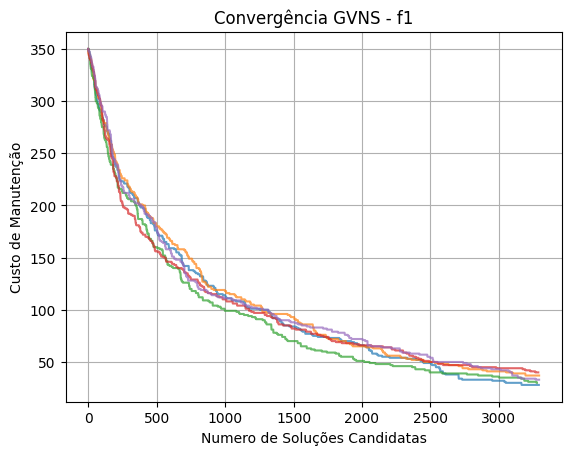

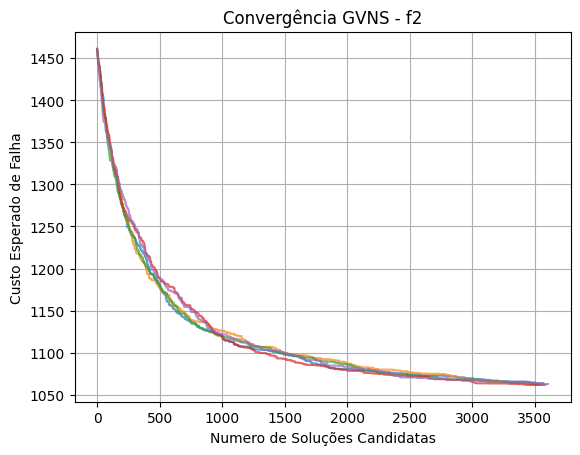

In [57]:
# GVNS

def GVNS(obj_func, equipDB, MPDB, Pij=None, max_iter=1000, return_curve=False):
    if obj_func == f2:
        assert Pij is not None, "Pij é obrigatória para a função f2."
    s = gerar_solucao_inicial(equipDB, Pij)
    melhor = s.copy()
    historico = []
    valor_inicial = obj_func(melhor, MPDB) if obj_func == f1 else obj_func(melhor, equipDB, MPDB, Pij)
    historico.append(valor_inicial)
    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, MPDB) if obj_func == f1 else busca_local(s_, obj_func, equipDB, MPDB, Pij)
            novo_valor = obj_func(s__, MPDB) if obj_func == f1 else obj_func(s__, equipDB, MPDB, Pij)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])
    return (melhor, historico) if return_curve else melhor

# Execução principal com 5 repetições
if __name__ == "__main__":
    resultados_f1 = [GVNS(f1, equipDB, MPDB, Pij,300, return_curve=True) for _ in range(5)]
    resultados_f2 = [GVNS(f2, equipDB, MPDB, Pij,300, return_curve=True) for _ in range(5)]

    custos_f1 = [f1(sol, MPDB) for sol, _ in resultados_f1]
    custos_f2 = [f2(sol, equipDB, MPDB, Pij) for sol, _ in resultados_f2]

    print("--- f1 (Custo de Manutenção) ---")
    print("Min:", np.min(custos_f1))
    print("Max:", np.max(custos_f1))
    print("Std:", np.std(custos_f1))

    print("\n--- f2 (Custo Esperado de Falha) ---")
    print("Min:", np.min(custos_f2))
    print("Max:", np.max(custos_f2))
    print("Std:", np.std(custos_f2))

    plt.figure()
    for _, hist in resultados_f1:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f1")
    plt.xlabel("Numero de Soluções Candidatas")
    plt.ylabel("Custo de Manutenção")
    plt.grid(True)
    plt.show()

    plt.figure()
    for _, hist in resultados_f2:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f2")
    plt.xlabel("Numero de Soluções Candidatas")
    plt.ylabel("Custo Esperado de Falha")
    plt.grid(True)
    plt.show()

--- f1 (Custo de Manutenção) ---
Min: 88.0
Max: 92.0
Std: 2.0

--- f2 (Custo Esperado de Falha) ---
Min: 1104.470389451927
Max: 1104.6182167567918
Std: 0.0739136524323385


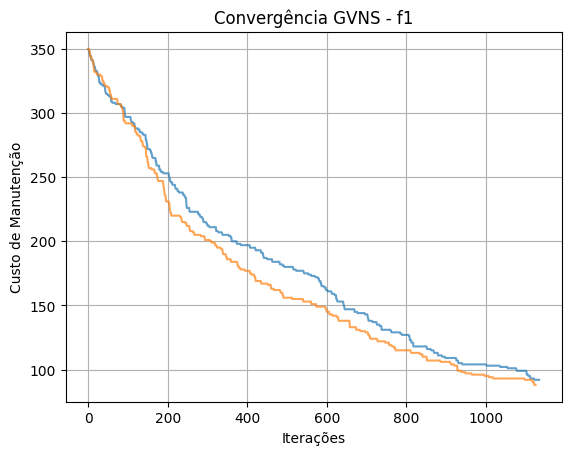

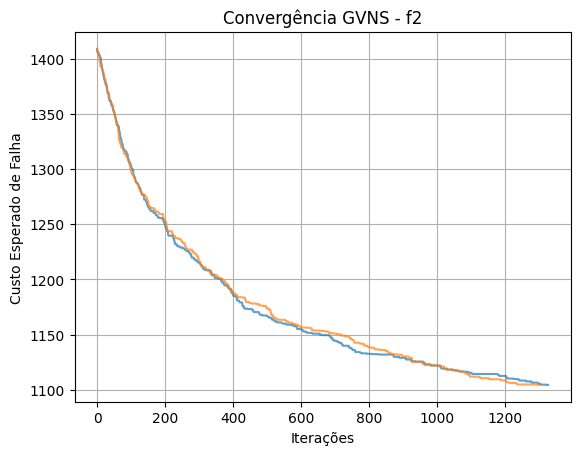

In [ ]:
def GVNS(obj_func,w, gerar_solucao_inicial, vizinhas, busca_local, *args, max_iter=1000, return_curve=False):
    """
    Algoritmo General Variable Neighborhood Search (GVNS) genérico.

    Parâmetros:
    - obj_func: função objetivo.
    - gerar_solucao_inicial: função que gera uma solução inicial.
    - vizinhas: lista de funções de vizinhança.
    - busca_local: função de busca local.
    - max_iter: número máximo de iterações.
    - return_curve: se True, retorna também o histórico dos valores.
    - *args, **kwargs: argumentos adicionais para as funções.

    Retorna:
    - melhor solução encontrada (e histórico se return_curve=True).
    """
    s = gerar_solucao_inicial(*args)
    melhor = s.copy()
    historico = []

    valor_inicial = obj_func(melhor,w, *args)
    historico.append(valor_inicial)

    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, *args)
            novo_valor = obj_func(s__,w, *args)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])

    return (melhor, historico) if return_curve else melhor


# Execução principal com 2 repetições
if __name__ == "__main__":
    # Defina suas funções e dados aqui antes de executar:
    # f1, f2: funções objetivo
    # gerar_solucao_inicial: função que cria uma solução inicial
    # move, double_move, block_change: operadores de vizinhança
    # busca_local: função de busca local
    # equipDB, MPDB, Pij: dados de entrada

    vizinhancas = [move, double_move, block_change]

    args = (equipDB, MPDB, Pij)

    resultados_f1 = [
        GVNS(f1, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=300, return_curve=True)
        for _ in range(2)
    ]

    resultados_f2 = [
        GVNS(f2, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=300, return_curve=True)
        for _ in range(2)
    ]

    custos_f1 = [f1(sol, args[0],args[1],args[2]) for sol, _ in resultados_f1]
    custos_f2 = [f2(sol, args[0],args[1],args[2]) for sol, _ in resultados_f2]

    print("--- f1 (Custo de Manutenção) ---")
    print("Min:", np.min(custos_f1))
    print("Max:", np.max(custos_f1))
    print("Std:", np.std(custos_f1))

    print("\n--- f2 (Custo Esperado de Falha) ---")
    print("Min:", np.min(custos_f2))
    print("Max:", np.max(custos_f2))
    print("Std:", np.std(custos_f2))

    plt.figure()
    for _, hist in resultados_f1:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f1")
    plt.xlabel("Iterações")
    plt.ylabel("Custo de Manutenção")
    plt.grid(True)
    plt.show()

    plt.figure()
    for _, hist in resultados_f2:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f2")
    plt.xlabel("Iterações")
    plt.ylabel("Custo Esperado de Falha")
    plt.grid(True)
    plt.show()


In [55]:
one = np.ones(500, dtype=int)

print("Menor f1 possível",f1(one,MPDB))
print("Maior f1 possível",f1(one+2,MPDB))
print("Menor f2 possível",f2(one+2,equipDB,MPDB,Pij))
print("Maior f2 possível",f2(one,equipDB,MPDB,Pij))

Menor f1 possível 0.0
Maior f1 possível 1000.0
Menor f2 possível 1048.178807842068
Maior f2 possível 1745.489826708262


In [56]:
for _, hist in resultados_f1:
    print(hist[len(hist)-1])

33.0
35.0
34.0
35.0
37.0


## Otimization $P_w$

--- f1 (Custo de Manutenção) ---
Min: 108.0
Max: 891.0
Std: 346.13055250150916

--- f2 (Custo Esperado de Falha) ---
Min: 1103.3423823557916
Max: 1656.0128529301417
Std: 245.26422556404825

Pesos W utilizados: [0.05457017313103085, 0.9025214812666332, 0.5773828828553615, 0.05363750551373703, 0.7045879910258482, 0.4161808377439977, 0.20896406086946318, 0.6611065648256498]


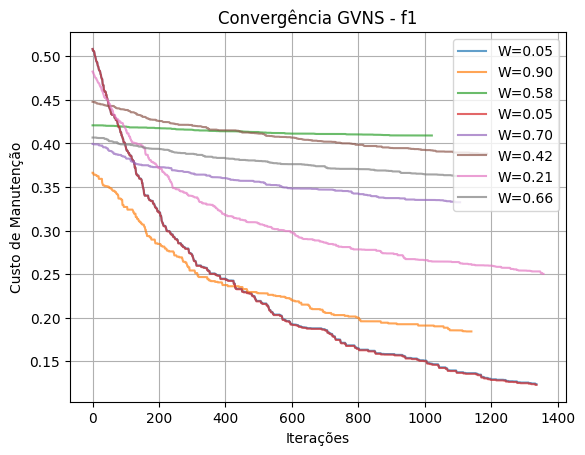

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random
import concurrent.futures
from multiprocessing import cpu_count


# --- Funções GVNS e auxiliares (sem alterações aqui exceto se usar global) ---

def GVNS(obj_func, gerar_solucao_inicial, vizinhas, busca_local, *args, max_iter=1000, return_curve=False):
    """
    Executa o algoritmo GVNS (Variable Neighborhood Search).
    """
    s = gerar_solucao_inicial(*args)
    melhor = s.copy()
    historico = []

    valor_inicial = obj_func(melhor, *args)
    historico.append(valor_inicial)

    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, *args)
            novo_valor = obj_func(s__, *args)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])

    return (melhor, historico) if return_curve else melhor


# --- Normalização da função objetivo ---
def normfObj(fobj, x, min_, max_, *args):
    """
    Normaliza o valor da função objetivo.
    """
    return (fobj(x, *args) - min_) / (max_ - min_)


# --- Função fábrica para criar a função objetivo com um W específico ---
def make_objf_Pw(W_local):
    """
    Retorna uma função objetivo ponderada com um valor W específico.
    """
    def objf_Pw(x, *args):
        return W_local * normfObj(f1, x, 0, 1000, *args) + (1 - W_local) * normfObj(f2, x, 1048, 1745.50, *args)
    return objf_Pw


# --- Wrapper para execução paralela ---
def run_gvns_wrapper(_):
    """
    Wrapper para a execução paralela do GVNS, retornando a solução e o peso W.
    """
    vizinhancas = [move, double_move, block_change]
    args = (equipDB, MPDB, Pij)
    W_local = random.uniform(0, 1)
    obj_func = make_objf_Pw(W_local)
    resultado = GVNS(obj_func, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=300, return_curve=True)
    return resultado, W_local  # Retorna a solução e o W utilizado


# Definir o número de iterações baseado no número de núcleos do processador
it = cpu_count()

if __name__ == "__main__":
    with concurrent.futures.ProcessPoolExecutor() as executor:
        resultados_com_pesos = list(executor.map(run_gvns_wrapper, range(it)))

    # Separando os resultados e os Ws
    resultados = [r[0] for r in resultados_com_pesos]
    pesos_W = [r[1] for r in resultados_com_pesos]

    custos_f1 = np.array([f1(sol, *args) for sol, _ in resultados])
    custos_f2 = np.array([f2(sol, *args) for sol, _ in resultados])

    # Exibindo estatísticas de custo
    print("--- f1 (Custo de Manutenção) ---")
    print("Min:", np.min(custos_f1))
    print("Max:", np.max(custos_f1))
    print("Std:", np.std(custos_f1))

    print("\n--- f2 (Custo Esperado de Falha) ---")
    print("Min:", np.min(custos_f2))
    print("Max:", np.max(custos_f2))
    print("Std:", np.std(custos_f2))

    print("\nPesos W utilizados:", pesos_W)

    # Plotando a convergência do GVNS
    plt.figure()
    for (_, hist), W_local in zip(resultados, pesos_W):
        plt.plot(hist, label=f"W={W_local:.2f}", alpha=0.7)
    plt.title("Convergência GVNS - f1")
    plt.xlabel("Iterações")
    plt.ylabel("Custo de Manutenção")
    plt.grid(True)
    plt.legend()
    plt.show()




=== Repetição 1/5 ===

=== Repetição 2/5 ===

=== Repetição 3/5 ===

=== Repetição 4/5 ===

=== Repetição 5/5 ===


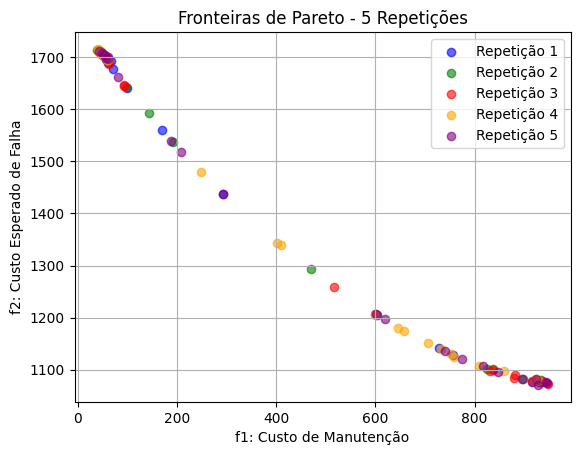

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import concurrent.futures
from multiprocessing import cpu_count
import time


# --- Funções GVNS e auxiliares (sem alterações aqui exceto se usar global) ---
def GVNS(obj_func, gerar_solucao_inicial, vizinhas, busca_local, *args, max_iter=1000, return_curve=False):
    """
    Executa o algoritmo GVNS (Variable Neighborhood Search).
    """
    s = gerar_solucao_inicial(*args)
    melhor = s.copy()
    historico = []

    valor_inicial = obj_func(melhor, *args)
    historico.append(valor_inicial)

    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, *args)
            novo_valor = obj_func(s__, *args)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])

    return (melhor, historico) if return_curve else melhor


# --- Normalização da função objetivo ---
def normfObj(fobj, x, min_, max_, *args):
    """
    Normaliza o valor da função objetivo.
    """
    return (fobj(x, *args) - min_) / (max_ - min_)


# --- Função fábrica para criar a função objetivo com um W específico ---
def make_objf_Pw(W_local):
    """
    Retorna uma função objetivo ponderada com um valor W específico.
    """
    def objf_Pw(x, *args):
        return W_local * normfObj(f1, x, 0, 1000, *args) + (1 - W_local) * normfObj(f2, x, 1048, 1745.50, *args)
    return objf_Pw


# --- Wrapper para execução paralela ---
def run_gvns_wrapper(_):
    """
    Wrapper para a execução paralela do GVNS, retornando a solução e o peso W.
    """
    vizinhancas = [move, double_move, block_change]
    args = (equipDB, MPDB, Pij)
    seed = int(time.time_ns() % (2**32))
    np.random.seed(seed)
    W_local = random.uniform(0, 1)
    obj_func = make_objf_Pw(W_local)
    resultado = GVNS(obj_func, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=600, return_curve=True)
    return resultado, W_local  # Retorna a solução e o W utilizado


def executar_uma_repeticao():
    with concurrent.futures.ProcessPoolExecutor(max_workers=32) as executor:
        resultados_com_pesos = list(executor.map(run_gvns_wrapper, range(it)))
    return resultados_com_pesos

def filtrar_pareto_nao_dominado(pontos):
    """Retorna apenas os pontos não dominados (fronteira de Pareto)"""
    pontos = np.array(pontos)
    n = pontos.shape[0]
    is_dominado = np.zeros(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i != j:
                # Dominância: queremos minimizar f1 e f2
                if (pontos[j][0] <= pontos[i][0] and pontos[j][1] <= pontos[i][1]) and \
                   (pontos[j][0] < pontos[i][0] or pontos[j][1] < pontos[i][1]):
                    is_dominado[i] = True
                    break
    return pontos[~is_dominado]

# Número de iterações a ser executado (por exemplo, 32 iterações)
it = 20 #intancias paraletas
repeticoes = 5

if __name__ == "__main__":
    todas_as_frentes_pareto = []

    for rep in range(repeticoes):
        print(f"\n=== Repetição {rep+1}/{repeticoes} ===")
        resultados_com_pesos = executar_uma_repeticao()
        args = (equipDB, MPDB, Pij)

        # Separando os resultados e os Ws
        resultados = [r[0] for r in resultados_com_pesos]
        pesos_W = [r[1] for r in resultados_com_pesos]

        custos_f1 = np.array([f1(sol, *args) for sol, _ in resultados])
        custos_f2 = np.array([f2(sol, *args) for sol, _ in resultados])

        # # Exibindo estatísticas de custo
        # print("--- f1 (Custo de Manutenção) ---")
        # print("Min:", np.min(custos_f1))
        # print("Max:", np.max(custos_f1))
        # print("Std:", np.std(custos_f1))

        # print("\n--- f2 (Custo Esperado de Falha) ---")
        # print("Min:", np.min(custos_f2))
        # print("Max:", np.max(custos_f2))
        # print("Std:", np.std(custos_f2))

        # print("\nPesos W utilizados:", pesos_W)

        # Plotando a convergência do GVNS
        #plt.figure()
        pareto = []
        for (sol, hist), W_local in zip(resultados, pesos_W):
            custo = f1(sol, *args)
            falha = f2(sol, *args)
            pareto.append((custo, falha))
        #     plt.plot(hist, label=f"W={W_local:.2f}", alpha=0.7)

        # plt.title(f"Convergência GVNS - f1 (Repetição {rep+1})")
        # plt.xlabel("Iterações")
        # plt.ylabel("Custo de Manutenção")
        # plt.grid(True)
        # plt.legend()
        # plt.show()

        # Armazena a fronteira de Pareto dessa repetição
        todas_as_frentes_pareto.append(np.array(pareto))

    # Plotando todas as fronteiras de Pareto
    plt.figure()
    cores = ['blue', 'green', 'red', 'orange', 'purple']
    for i, fronteira in enumerate(todas_as_frentes_pareto):
        fronteira_nd = filtrar_pareto_nao_dominado(fronteira)
        plt.scatter(fronteira[:, 0], fronteira[:, 1], label=f"Repetição {i+1}", alpha=0.6, color=cores[i % len(cores)])

    #plt.title("Fronteiras de Pareto - 5 Repetições")
    plt.xlabel("f1: Custo de Manutenção")
    plt.ylabel("f2: Custo Esperado de Falha")
    plt.grid(True)
    plt.legend()
    plt.show()

## Otimization $P_{\epsilon}$